# 09 · Independent validation and model selection

**ROBT613 · Brain–Computer Interfaces** | Academic tutorial and independent exercises

## Goal
Compare classifiers with nested run-grouped validation, distinguish uncertainty units and diagnose leakage.

**Data:** EEGBCI subject 1, three independent run groups

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## Paradigm background and experimental design

### Motor imagery and sensorimotor rhythms

Motor imagery is the internal rehearsal of movement without overt execution. In a sensorimotor-rhythm BCI, the intended action is inferred from changes in oscillatory activity, commonly within the mu and beta ranges. Event-related desynchronization denotes reduced band power relative to a reference interval; it does not mean that the EEG voltage becomes uniformly negative. The spatial and temporal distributions are variable across participants and trials.

A minimal cue-based experiment presents a fixation interval followed by a left- or right-hand instruction, an imagery interval and a rest interval. The participant imagines the kinesthetic sensation of movement while maintaining posture. An EEG cap, amplifier and acquisition computer record continuous signals; a stimulus computer records cue onset and class. Additional EOG or EMG channels, when actually acquired, can support artifact assessment. Their presence must not be assumed from scalp EEG alone.

A trial is one instructed imagery interval; a run is a sequence of trials; a session is a recording visit. These levels are not exchangeable independent samples. Run-wise evaluation assesses transfer across recording blocks, whereas subject-wise evaluation addresses a different generalization claim. Averaging signed voltages can suppress induced rhythms whose phases vary between trials; band power or time–frequency estimates are therefore central measurements.

### Acquisition provenance and instructional protocol

PhysioNet EEGBCI: 64 scalp channels, 160 Hz. Runs 4, 8 and 12 encode imagined left/right fist movement; individual lessons may use only run 4. Acquisition used BCI2000. The original database also contains executed movements and other imagery tasks.

**Acquisition reference:** [PhysioNet EEG Motor Movement/Imagery Dataset](https://physionet.org/content/eegmmidb/1.0.0/). The sampling rate of processed epochs can differ from the original acquisition rate after explicit resampling.

| Experimental component | Required record and analytical purpose |
|---|---|
| Participant instruction | Defines the task and distinguishes attention, imagery and execution |
| Stimulus/event clock | Provides onset markers for alignment; its synchronization must be documented |
| Measurement hardware | Records sensor type, locations, reference and original sampling frequency |
| Trial, run and session log | Preserves dependence structure and supports appropriate validation |
| Quality observations | Records movement, contact failures and rejected intervals without changing labels |

**Experimental sequence:** Cue and task instruction → continuous EEG → imagery epoch → spectral/spatial features. Exact cue durations and hardware settings must be obtained from the original protocol; the analysis windows below are explicitly chosen processing intervals.

### Measurement model and interpretation

For EEG, a sensor measures a potential difference, not neuronal firing rate. The observed signal combines neural activity, physiological interference, environmental interference and measurement noise. Filtering or projection changes this mixture and cannot establish that the remaining signal is exclusively neural. For fNIRS, replace the electrical measurement model with the optical model defined below. Experimental labels are external observations; they must not be reconstructed from a classifier's predictions.

### Mathematical definitions for this lesson

Let $G_i$ denote the run or session of observation $i$. Grouped validation requires $\{G_i:i\in\mathcal I_{train}\}\cap\{G_i:i\in\mathcal I_{test}\}=\varnothing$. Nested validation chooses hyperparameters using inner training partitions, then estimates performance using the outer held-out group. Balanced accuracy is $K^{-1}\sum_{k=1}^K TP_k/(TP_k+FN_k)$. It weights classes equally, but does not remove dependence among repeated measurements.

Throughout, $i$ indexes trials, $c$ channels, $k$ samples, $N$ trials, $C$ channels and $T$ samples per trial unless a local definition states otherwise. An EEG epoch array has shape $(N,C,T)$; classifier features have shape $(N,d)$. A change of representation must preserve the correspondence between observations and labels.


**Methodological reading:** [Blankertz et al. (2008). Optimizing spatial filters for robust EEG single-trial analysis](https://doi.org/10.1109/MSP.2008.4408441). Spatial covariance methods for decoding.

## How to study this notebook

This is both the classroom lesson and the independent-study workbook. Everything needed for the exercises—questions, hints, executable solutions, checks and explanations—is here. Work from top to bottom in a fresh runtime.

1. Read the question and calculate a small example on paper.
2. Write your prediction before running the next code cell.
3. Complete the analytical task in its workspace.
4. Continue to the worked solution and compare the reasoning, as well as the numerical result.
5. Change one parameter and explain what the result means.

**For a live class:** pause at each “Independent exercise” heading. The solution follows in the same notebook, so no separate answer document is required. Saved figures support reading without execution; downloading real data and rerunning cells requires internet on the first run. Code comments explain each analysis statement, and longer loops are explained before execution.

**Prerequisites:** basic Python arrays, arithmetic and plotting. The symbol guide below defines the mathematical notation used here. These lessons stay at the sensor level; EEG source imaging is outside the course.

## Analytical objectives

This lesson examines the relationship between the experimental task, the measured signal and the assumptions of the analysis. Interpret each computational result in relation to the acquisition protocol and the stated evaluation design.

### Learning outcomes

- Match run, session and participant grouping to the target use case.
- Explain inner selection and outer evaluation in nested validation.
- Calculate class-balanced metrics and distinguish scores from uncertainty.
- Identify every learned preprocessing operation that must be refitted within folds.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The first worked examples use controlled arrays; the later walkthrough and applied practice use the dataset stated above. Practice workspaces, hints and worked solutions are placed beside the relevant methods. Complete your attempt before continuing to the reference solution.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


## Visual route through the lesson

Follow the arrows before running the analysis. For each box, say what the input represents, what changes, and what must be preserved.

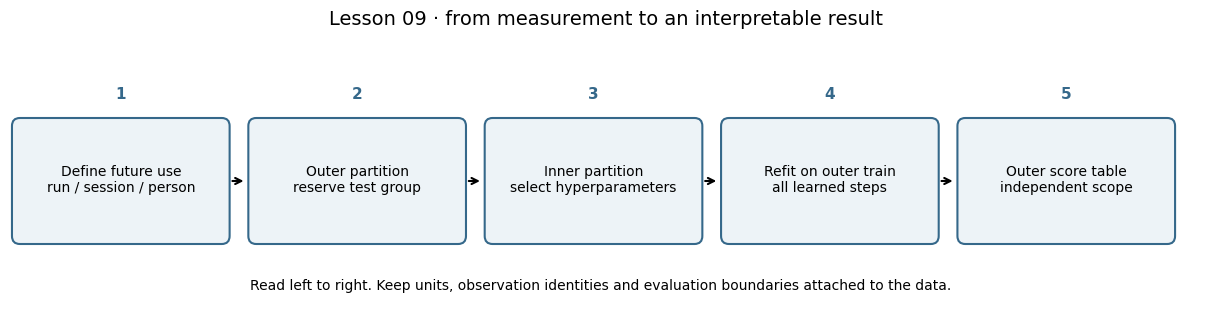

In [2]:
# Drawing code for the lesson map; no analysis data are transformed here.
from matplotlib.patches import FancyBboxPatch
map_steps=['Define future use\nrun / session / person', 'Outer partition\nreserve test group', 'Inner partition\nselect hyperparameters', 'Refit on outer train\nall learned steps', 'Outer score table\nindependent scope']
fig,map_ax=plt.subplots(figsize=(12,3.1),constrained_layout=True)
map_ax.set(xlim=(-.1,12),ylim=(-.3,2.4));map_ax.axis('off')
for map_i,map_label in enumerate(map_steps):
    map_x=map_i*2.4
    map_ax.add_patch(FancyBboxPatch((map_x,.45),2.05,1.1,
        boxstyle='round,pad=0.08',facecolor='#edf3f7',edgecolor='#35688a',linewidth=1.5))
    map_ax.text(map_x+1.025,1.02,map_label,ha='center',va='center',fontsize=10)
    map_ax.text(map_x+1.025,1.83,str(map_i+1),ha='center',weight='bold',color='#35688a')
    if map_i<4:map_ax.annotate('',xy=(map_x+2.3,1),xytext=(map_x+2.13,1),arrowprops=dict(arrowstyle='->',lw=1.5))
map_ax.text(5.9,-.08,'Read left to right. Keep units, observation identities and evaluation boundaries attached to the data.',ha='center',fontsize=10)
map_ax.set_title('Lesson 09 · from measurement to an interpretable result',fontsize=14,pad=12)
plt.show()

**Read the map:** the arrows represent processing order, not permission to fit on all observations. When a stage learns parameters, keep evaluation data outside that fit. The map is also available as text: Define future use: run / session / person → Outer partition: reserve test group → Inner partition: select hyperparameters → Refit on outer train: all learned steps → Outer score table: independent scope.

## Symbols and a calculation by hand

$G$: grouping variable; $h$: hyperparameters; $k$: outer fold; $s_k$: outer score; $K$: classes.

### Derive the operation before calling the library

Within outer fold $k$, choose $\hat h_k=\arg\max_h\operatorname{CV}_{inner}(h,D_{train,k})$. Refit that configuration on $D_{train,k}$ and score it once on $D_{test,k}$. The test group takes no part in either choice or fit.

For three runs A/B/C, one outer fold reserves C and performs inner A→B and B→A comparisons. It then refits on A+B and evaluates on C. Rotate the outer held-out run to obtain three descriptive scores. Balanced accuracy is $K^{-1}\sum_kTP_k/(TP_k+FN_k)$: an all-majority predictor on a binary 90/10 dataset has accuracy 0.9 but balanced accuracy $(1+0)/2=0.5$.

### Your paper calculation

Rewrite one equation with the numerical example above. Name the input units and output units, and identify the axis being reduced or transformed.

**My calculation:** _write your intermediate steps here before continuing._

### Choose the prediction problem before the split

A random trial split asks whether a model generalizes to another trial under closely shared recording conditions. A held-out run asks a stronger question about a new recording block. A held-out session tests changes across sessions; a held-out participant tests transfer across people. None is a substitute for another. The partition is part of the experiment, not a final programming detail.

Adjacent EEG windows can share samples, artifacts and slow changes. Even non-overlapping trials in the same run share impedance, fatigue, amplifier conditions and task order. Grouped cross-validation holds entire groups out. If the intended deployment has a temporal direction, ensure the evaluation also respects that direction; ordinary grouped folds do not by themselves simulate chronological deployment.

### Learn only from the training partition

A transformation is “learned” whenever it estimates parameters from data. Standardization estimates means and variances. PCA estimates directions. CSP estimates label-dependent spatial filters. Feature selection estimates which columns to keep. All belong inside the fold when evaluating the full pipeline. A fixed physical unit conversion does not estimate a parameter and can be applied consistently in advance.

Hyperparameters include component count, regularization, bands selected by performance and decision thresholds selected by performance. Repeatedly trying them against a test set makes the test set part of the training process, even if no gradient was computed on it.

### Two loops with different jobs

For each outer fold, set aside the outer test group. Within the remaining groups, inner validation selects one candidate configuration. Refit that configuration on all outer training data, then evaluate once on the outer test group. The outer scores describe the model-selection procedure, not one model fitted to every observation.

$$\hat h_k=\arg\max_h\operatorname{CV}_{inner}(h;D_{train,k}),\qquad s_k=\operatorname{score}(\operatorname{fit}(\hat h_k,D_{train,k}),D_{test,k}).$$

The nested example has few groups, so estimates can be noisy. A table of individual run scores is more informative than a mean with many decimal places. Fold scores are not independent participants; treating them as such produces unjustified precision.

### Metrics and uncertainty

Balanced accuracy averages class recalls, $BA=K^{-1}\sum_k TP_k/(TP_k+FN_k)$. ROC AUC describes ranking for a binary score; it does not choose a useful operating threshold. A confusion matrix shows which classes are confused but depends on a decision rule. Report the class counts and the evaluation unit alongside any metric.

Permutation tests require exchangeability under the null. Arbitrarily shuffling individual trials can break temporal or block structure. Bootstrap intervals likewise depend on the unit resampled: trials, runs and participants support different claims. This lesson teaches the reasoning and avoids presenting three folds as a precise population confidence interval.

## Visual intuition · Separate outer testing from inner selection

**Independent exercise:** Trace the row where C is the outer test run. Which observations can select a component count?

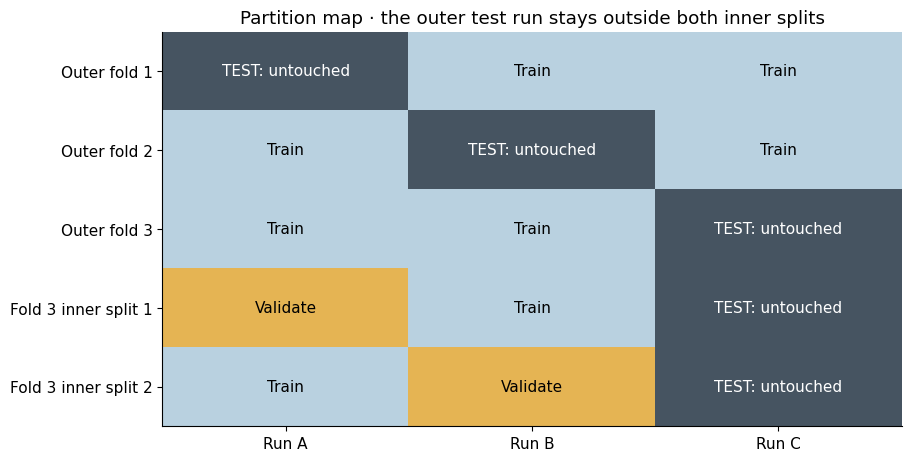

In [3]:
from matplotlib.colors import ListedColormap
vis_roles=np.array([[2,1,1],[1,2,1],[1,1,2],[0,1,2],[1,0,2]])
vis_labels=['Outer fold 1','Outer fold 2','Outer fold 3','Fold 3 inner split 1','Fold 3 inner split 2']
fig,ax=plt.subplots(figsize=(9,4.5),constrained_layout=True)
ax.imshow(vis_roles,cmap=ListedColormap(['#e5b453','#b9d1e0','#465461']),vmin=0,vmax=2,aspect='auto')
for row in range(5):
    for col in range(3):ax.text(col,row,['Validate','Train','TEST: untouched'][vis_roles[row,col]],ha='center',va='center',color='white' if vis_roles[row,col]==2 else 'black')
ax.set(xticks=range(3),xticklabels=['Run A','Run B','Run C'],yticks=range(5),yticklabels=vis_labels,title='Partition map · the outer test run stays outside both inner splits')
plt.show()

### Worked interpretation

In outer fold 3, A and B exchange training/validation roles while C remains untouched. After selection, refit on A+B, then evaluate once on C. The two lower rows illustrate only fold 3, not two additional independent tests.

## Guided practice 1 · imbalanced accuracy

Construct a 90/10 dataset and predict only the majority class.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [4]:
from sklearn.metrics import accuracy_score
demo_y=np.array([0]*90+[1]*10)
demo_pred=np.zeros(100,dtype=int)
print('Accuracy:',accuracy_score(demo_y,demo_pred),'Balanced accuracy:',balanced_accuracy_score(demo_y,demo_pred))

Accuracy: 0.9 Balanced accuracy: 0.5


### Why this result makes sense

Ninety percent accuracy can coexist with zero sensitivity to the minority class. The metric must reflect the scientific objective.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 2 · inspect grouped folds

Use three groups and print the identifiers in each partition. Assert that no group crosses a boundary.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [5]:
demo_groups=np.repeat(['run A','run B','run C'],4)
demo_y=np.tile([0,1,0,1],3)
for train_idx,test_idx in GroupKFold(3).split(np.zeros((12,1)),demo_y,demo_groups):
    assert set(demo_groups[train_idx]).isdisjoint(demo_groups[test_idx])
    print('Train:',np.unique(demo_groups[train_idx]),'Test:',np.unique(demo_groups[test_idx]))

Train: ['run A' 'run B'] Test: ['run C']
Train: ['run A' 'run C'] Test: ['run B']
Train: ['run B' 'run C'] Test: ['run A']


### Why this result makes sense

Checking group identities is more direct than assuming a splitter did what the experiment required.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 3 · fitting the scaler

Compare training-only and pooled means when the held-out data have shifted.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [6]:
demo_train=np.array([[0.],[1.],[2.]])
demo_test=np.array([[10.],[11.]])
demo_scaler=StandardScaler().fit(demo_train)
print('Training mean:',demo_scaler.mean_)
print('Pooled mean:',np.vstack([demo_train,demo_test]).mean(axis=0))
print('Test transformed by training parameters:',demo_scaler.transform(demo_test).ravel())

Training mean: [1.]
Pooled mean: [4.8]
Test transformed by training parameters: [11.02270384 12.24744871]


### Why this result makes sense

The shifted test values should remain shifted. Using their mean during fitting partly adapts to the evaluation distribution and changes the question being measured.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Guided practice 4 · selection optimism

Imagine twenty equally good candidates whose validation estimates contain noise. Compare the maximum observed estimate with their shared true value.

**Independent exercise on paper:** predict the output’s shape, sign or approximate value. State which assumption makes your prediction valid.

**My prediction:** _write here._

**Hint:** trace one sample, one channel or one trial through the calculation before considering the full array.

### Worked solution · read one statement at a time

In [7]:
demo_rng=np.random.default_rng(613)
demo_estimates=.6+demo_rng.normal(0,.05,size=(1000,20))
print('Mean of all estimates:',demo_estimates.mean())
print('Mean selected maximum:',demo_estimates.max(axis=1).mean())

Mean of all estimates: 0.6003243336953168
Mean selected maximum: 0.6935301026005202


### Why this result makes sense

Selecting the largest noisy estimate inflates its apparent performance. An untouched outer evaluation is needed even when every candidate has identical true quality.

**Check your understanding:** change one numerical parameter, predict the direction of change, and rerun. If the result disagrees, inspect units and axes before changing the method.

## Practice 1 · Group assertion

Implement groups_disjoint to return whether train and test contain no shared group identifiers.

**Independent exercise:** complete the function below before reading its solution. The template deliberately returns None so that an unfinished attempt does not interrupt the rest of the lesson.

In [8]:
def groups_disjoint(train_groups, test_groups):
    # TODO: return a Boolean.
    return None

### Hint

Use the equation above and keep the trial/channel axes intact unless the requested output removes them. Test the smallest example by hand first.

### Worked solution

Compare this implementation with your attempt. The next cell checks the reference answer on a concrete numerical case.

In [9]:
def groups_disjoint(train_groups,test_groups):
    return set(train_groups).isdisjoint(set(test_groups))

In [10]:
answer=groups_disjoint(['A','B'],['C'])
if answer is not None:
    assert answer
    assert not groups_disjoint(['A','B'],['B','C'])
    print('Group checks passed.')
else: print('Exercise pending: implement groups_disjoint.')

Group checks passed.


## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

A test score estimates performance on the distribution represented by the held-out unit. Holding out trials, runs, sessions and people answers different questions. If adjacent windows share EEG samples, random window splitting can make generalization look much stronger than it is.

Nested cross-validation separates model selection from evaluation: for each outer split, choose hyperparameters using only inner folds of the outer training set, refit, then score the outer test set once. For balanced accuracy $BA=K^{-1}\sum_k TP_k/(TP_k+FN_k)$. A confusion matrix reveals which classes contribute to a mean score.

A bootstrap must resample independent units. Thousands of correlated epochs from one participant do not provide thousands of independent estimates of population performance. Three run scores are too few for a precise uncertainty estimate. Permutation tests must respect exchangeability (e.g. experimental blocks); shuffling arbitrary overlapping flash labels is not automatically valid.

## Load an auditable benchmark
This lesson deliberately keeps all three run IDs.

Preserve run groups while loading and processing each run separately. The nested evaluation needs those identifiers to distinguish inner development from outer assessment.

### Step 1.1 · trace the next operation

**1.** Import the named tools used in this step.

**2.** Make the analysis choice visible and fixed before inspecting evaluation performance.

**3.** Store this intermediate result so the next operation can be traced and inspected.

In [11]:
# Import the named tools used in this step.
from mne.datasets import eegbci
# Make the analysis choice visible and fixed before inspecting evaluation performance.
runs = [4, 8, 12]
# Store this intermediate result so the next operation can be traced and inspected.
parts, groups = ([], [])

### Step 1.2 · trace the next operation

**1.** Process each run independently; carry its run ID into every resulting trial.

In [12]:
# Process each run independently; carry its run ID into every resulting trial.
for run in runs:
    # Retrieve this run independently so filtering does not cross a run boundary.
    paths = eegbci.load_data(1, [run], path=DATA_ROOT, update_path=False)
    # Load this run’s continuous recording and its sampling metadata.
    raw_run = mne.io.read_raw_edf(paths[0], preload=True, verbose=False)
    # Make sensor names consistent with the montage and later channel selections.
    eegbci.standardize(raw_run)
    # Attach sensor locations; no anatomical inverse model is used.
    raw_run.set_montage('standard_1005')
    # Use the same reference convention for every run.
    raw_run.set_eeg_reference('average', projection=False)
    # Filter the continuous run before extracting its trials.
    raw_run.filter(8, 30, fir_design='firwin')
    # Map only the documented imagery cues to the two class codes.
    events, _ = mne.events_from_annotations(raw_run, event_id={'T1': 1, 'T2': 2})
    # Extract the stated post-cue interval while retaining condition labels.
    ep = mne.Epochs(raw_run, events, {'left': 1, 'right': 2}, tmin=0.5, tmax=3.5, baseline=None, preload=True, picks='eeg', reject_by_annotation=True)
    # Retain this run’s epoch object for the later concatenation.
    parts.append(ep)
    # Append exactly one run identifier for every retained trial.
    groups.extend([run] * len(ep))

/tmp/ipykernel_476805/1290271967.py:10: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw_run.set_montage('standard_1005')


/tmp/ipykernel_476805/1290271967.py:10: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw_run.set_montage('standard_1005')
/tmp/ipykernel_476805/1290271967.py:10: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw_run.set_montage('standard_1005')


### Step 1.3 · trace the next operation

**1.** Join trial collections while retaining one aligned group label per trial.

**2.** Expose the numerical array; EEG values are in volts and the final axis is time.

**3.** Keep one label or grouping identifier per trial in exactly the same order as the EEG array.

**4.** Make an explicit NumPy vector while preserving its current row order.

**5.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [13]:
# Join trial collections while retaining one aligned group label per trial.
epochs = mne.concatenate_epochs(parts)
# Expose the numerical array; EEG values are in volts and the final axis is time.
X = epochs.get_data(copy=True)
# Keep one label or grouping identifier per trial in exactly the same order as the EEG array.
y = epochs.events[:, 2] - 1
# Make an explicit NumPy vector while preserving its current row order.
groups = np.asarray(groups)
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print('Epochs:', X.shape, 'run counts:', pd.Series(groups).value_counts().to_dict())

Epochs: (45, 64, 481) run counts: {4: 15, 8: 15, 12: 15}


/tmp/ipykernel_476805/2710259772.py:2: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs = mne.concatenate_epochs(parts)


### Inspect and interpret

Inspect group sizes and class balance. Consider whether the available number of groups is adequate for a large hyperparameter search.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 2 · List the groups in one outer and inner split

**Independent exercise:** Print one outer partition and the two inner partitions within its training set. Verify that the outer test run never appears inside.

**My reasoning / hand calculation:** _write here._

In [14]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

Inner indices refer to the outer-training array, not directly to the original full array.

### Worked solution

Run the following calculation after attempting your own version.

In [15]:
lab_outer_train,lab_outer_test=next(GroupKFold(3).split(X,y,groups))
print('Outer test:',np.unique(groups[lab_outer_test]))
for lab_it,lab_iv in GroupKFold(2).split(X[lab_outer_train],y[lab_outer_train],groups[lab_outer_train]):
    lab_tgroups=groups[lab_outer_train][lab_it]
    lab_vgroups=groups[lab_outer_train][lab_iv]
    print('Inner train:',np.unique(lab_tgroups),'inner validation:',np.unique(lab_vgroups))
    assert set(lab_tgroups).isdisjoint(groups[lab_outer_test])
    assert set(lab_vgroups).isdisjoint(groups[lab_outer_test])

Outer test: [12]
Inner train: [4] inner validation: [8]
Inner train: [8] inner validation: [4]


### Interpret and check

The index mapping is a common source of mistakes. Inner indices select rows within outer-training data. Applying those indices directly to full X would silently select different observations and could invalidate the split.

## Nested model comparison
With three runs, each outer training fold contains two runs, so the inner loop uses two groups. All learned transformations remain inside the pipeline.

The outer loop holds out one run. Inner grouped search chooses CSP component count using only the other two runs. Each row records the held-out result for a complete model-selection procedure.

### Step 2.1 · trace the next operation

**1.** Import the named tools used in this step.

**2.** Hold entire recording groups out rather than mixing neighboring trials.

**3.** Initialize the collection that will retain outputs in the same order as the inputs.

In [16]:
# Import the named tools used in this step.
from mne.decoding import CSP
# Hold entire recording groups out rather than mixing neighboring trials.
outer = GroupKFold(3)
# Initialize the collection that will retain outputs in the same order as the inputs.
rows = []

### Step 2.2 · trace the next operation

**1.** Reserve an outer run, select the model only inside remaining runs, then score the untouched run.

In [17]:
# Reserve an outer run, select the model only inside remaining runs, then score the untouched run.
for fold, (tr, te) in enumerate(outer.split(X, y, groups), 1):
    # Fit representation and classifier together within the permitted training partition.
    model = make_pipeline(CSP(n_components=4, reg='ledoit_wolf', log=True), LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
    # Search only within the outer-training runs; the outer test remains untouched.
    search = GridSearchCV(model, {'csp__n_components': [2, 4]}, cv=GroupKFold(2), scoring='balanced_accuracy', n_jobs=1)
    # Supply only outer-training observations and their inner grouping labels.
    search.fit(X[tr], y[tr], groups=groups[tr])
    # Score the held-out group after selection, averaging recalls across classes.
    score = balanced_accuracy_score(y[te], search.predict(X[te]))
    rows.append({'held_out_run': int(groups[te][0]), 'balanced_accuracy': score, 'components': search.best_params_['csp__n_components']})

### Step 2.3 · trace the next operation

**1.** Store this intermediate result so the next operation can be traced and inspected.

**2.** Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.

In [18]:
# Store this intermediate result so the next operation can be traced and inspected.
results = pd.DataFrame(rows)
# Display a bounded diagnostic; read the units, shape or partition rather than treating output as a success label.
print(results)

   held_out_run  balanced_accuracy  components
0            12           0.616071           2
1             8           0.660714           4
2             4           0.562500           4


### Step 2.4 · trace the next operation

**1.** Create axes; plotting changes the display, not the analyzed data.

**2.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**3.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**4.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**5.** Apply the stated operation to the current object; use the surrounding explanation to check its role.

**6.** Render the completed figure and inspect labels, units and the comparison.

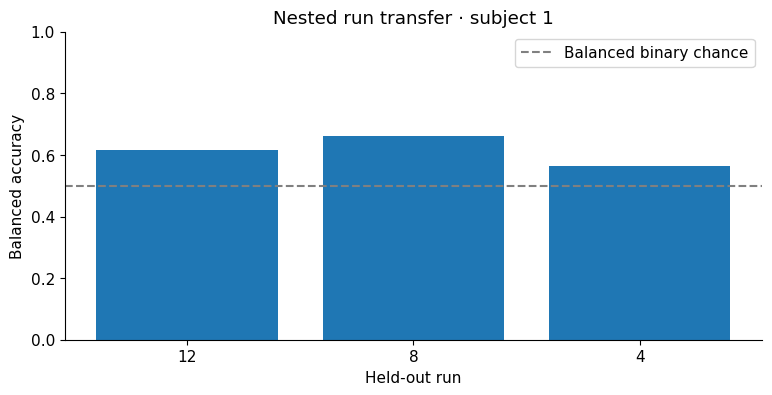

In [19]:
# Create axes; plotting changes the display, not the analyzed data.
fig, ax = plt.subplots()
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.bar(results.held_out_run.astype(str), results.balanced_accuracy)
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.axhline(0.5, color='gray', linestyle='--', label='Balanced binary chance')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.set(ylim=(0, 1), xlabel='Held-out run', ylabel='Balanced accuracy', title='Nested run transfer · subject 1')
# Apply the stated operation to the current object; use the surrounding explanation to check its role.
ax.legend()
# Render the completed figure and inspect labels, units and the comparison.
plt.show()

### Inspect and interpret

Compare outer scores, chosen configurations and run-specific errors. A variable selected configuration may indicate that the calibration sample is too small to identify one stable optimum.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Practice 3 · Report scores without artificial precision

**Independent exercise:** Display the per-run scores and their mean/range. Write a conclusion limited to these runs.

**My reasoning / hand calculation:** _write here._

In [20]:
# Your attempt goes here. Work on copies and preserve the evaluation split.

### Hint

Three run scores from one person are not three independent participant estimates.

### Worked solution

Run the following calculation after attempting your own version.

In [21]:
print(results[['held_out_run','balanced_accuracy','components']])
print('Mean:',results.balanced_accuracy.mean())
print('Range:',results.balanced_accuracy.min(),results.balanced_accuracy.max())

   held_out_run  balanced_accuracy  components
0            12           0.616071           2
1             8           0.660714           4
2             4           0.562500           4
Mean: 0.6130952380952381
Range: 0.5625 0.6607142857142857


### Interpret and check

A valid conclusion describes variation in held-out-run performance for this participant under the stated selection procedure. It cannot establish population performance or a precise confidence interval across people. Do not choose the best outer fold and report it as the overall result.

## Practice 4 · Choose the evaluation unit for deployment

**Independent exercise:** Match three intended uses to appropriate partitions: new block today, another day, a new participant.

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

The partition should withhold the source of variation you claim to generalize across.

### Worked solution

A new block calls for held-out runs or chronological blocks; another day calls for held-out sessions/days; a new person calls for held-out participants. If deployment is chronological, the training data must precede the evaluation data. Grouping alone does not enforce time direction.

## Practice 5 · Respond to test-set reuse

**Independent exercise:** After seeing the final score, a team changes bands repeatedly until accuracy improves. What can the revised score legitimately be called?

**My reasoning / hand calculation:** _write here._

**My answer:** _write a short explanation before continuing._

### Hint

The test observations have now influenced development.

### Worked solution

It is an exploratory result on reused evaluation data. Document the changes and obtain a new independent test before making a confirmatory claim. There is no correction that restores the original untouched status merely by renaming the partition.

## Recorded-signal inspection with MNE-Python

The following visualization uses the recording analysed in this notebook. The API retains channel names, sample timing and physical units. This is descriptive inspection; it does not authorize selecting parameters on held-out labels.

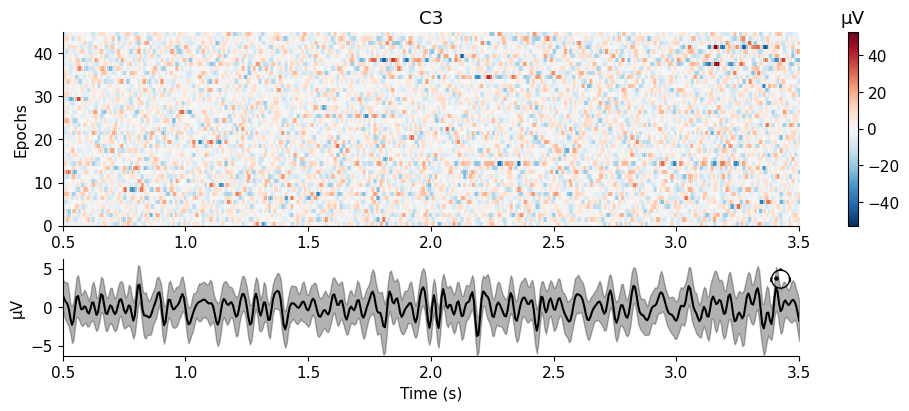

In [22]:
# Display individual recorded trials with MNE's epoch-image API.
inspection_epochs = epochs.copy().pick(['C3'])
inspection_epochs.plot_image(picks=['C3'], sigma=0, show=False)
plt.show()

### Figure interpretation and independent exercise

The image displays individual trials at C3; colour encodes voltage and the lower panel summarizes the evoked response. Inspect amplitude variability and temporal alignment. For motor imagery and SSVEP, a weak signed average can coexist with substantial induced or frequency-locked power; interpret this display alongside the spectral analysis. Trial order follows the loaded epoch object and is not a randomized validation split.

**Exercise.** Identify the measurement unit, the observation represented by each trace or image row, and one conclusion that the figure cannot support. Explain how the answer changes if the signal has already been filtered.

**Reference interpretation.** The displayed observations are processed sensor measurements, not independent participants. Filtering changes the measured bandwidth and temporal structure. The plot supports quality assessment and descriptive comparisons; it does not establish causal neural mechanisms, source location or out-of-sample classification performance.

## Practice 6 · explain the complete method

Independently explain the measurement, transformation, feature or summary, and the evaluation boundary. Include one failure mode and one claim the result does not establish.

**My explanation:** _write here._

### Worked answer · compare your reasoning

The split defines the future-use claim. Inner validation selects a configuration; outer testing assesses that selection procedure. Every learned transformation respects the boundary. Repeated use of a test result for design turns it into development data.

## If your result is different

If inner splits fail, count distinct groups inside the outer-training set. Reduce the search/fold count appropriately; never borrow the outer test group to make a fold possible.

If a dataset download fails, read the error and retry when the public host is reachable; do not silently replace real data with simulated values. If a notebook cell refers to an undefined variable, restart the kernel and run the preceding cells in order. Numerical scores can vary slightly with library versions; record versions and compare the protocol before concluding that a method changed.

## Can you now do this independently?

- Explain each arrow in the lesson map and the units at its boundaries.
- Reproduce the hand calculation and point to its corresponding code.
- Interpret the figures without turning a descriptive pattern into an unsupported causal claim.
- Complete a practice task before reading its worked solution.
- State which choices were fixed and which were learned from calibration data.

If one item is unclear, return to the associated figure or practice section before the next lesson.

## Next steps and sources
[Cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html) · [Common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.

## References and further reading

1. [Gramfort et al. (2013), MEG and EEG data analysis with MNE-Python](https://doi.org/10.3389/fnins.2013.00267). Core data structures and reproducible electrophysiological analysis.
2. [PhysioNet EEG Motor Movement/Imagery Dataset](https://physionet.org/content/eegmmidb/1.0.0/). Acquisition provenance, task definition and dataset-specific interpretation.
3. [MNE-Python API reference](https://mne.tools/stable/python_reference.html). Consult the documented units, defaults and return values of each method.
4. [MNE overview tutorial](https://mne.tools/stable/auto_tutorials/intro/10_overview.html). Relationship between continuous data, epochs and evoked responses.
5. [MNE documentation on in-place modification](https://mne.tools/stable/auto_tutorials/intro/15_inplace.html). Object copying and preservation of analysis branches.

These references support the acquisition and software descriptions. Numerical outcomes in this notebook refer only to the explicitly selected data and evaluation design; they are not population performance estimates. Dataset terms remain separate from the licence of these teaching materials.


### Primary methodological literature

- [Blankertz et al. (2008). Optimizing spatial filters for robust EEG single-trial analysis](https://doi.org/10.1109/MSP.2008.4408441). Spatial covariance methods for decoding.